In [358]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [359]:
import os
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

.\MegaSena_CSVDataset.ipynb
.\MegaSena_Dezena.csv
.\MegaSena_Dezena.ipynb
.\MegaSena_Dezena_CRS.csv
.\MegaSena_Dezena_CSV.ipynb
.\MegaSena_Dezena_Sorteio.csv
.\MegaSena_Dezena_SRT.csv
.\MegaSena_Final.ipynb
.\MegaSena_Predict.csv
.\MegaSena_Predict.ipynb
.\MegaSena_Torch_CSV.ipynb
.\MegaSena_Torch_MLP.csv
.\MegaSena_Torch_MLP.ipynb
.\mega_sena_asloterias_ate_concurso_2404_crescente.xlsx
.\mega_sena_asloterias_ate_concurso_2404_sorteio.xlsx
.\mega_sena_crescente.csv
.\mega_sena_sorteio.csv


In [360]:
#filepath = './MegaSena_Dezena_CRS.csv'
filepath = './MegaSena_Dezena_SRT.csv'
mega_data = pd.read_csv(filepath)
mega_data = mega_data.sort_values('Date')
mega_data.head(5)
mega_data.tail(5)
#flight_data = sns.read_csv("flights")
#flight_data.head()
mega_field = 'Value3'

In [361]:
mega_data.shape

(2405, 8)

In [362]:
fig_size = plt.rcParams["figure.figsize"]
fig_size[0] = 25
fig_size[1] = 5
plt.rcParams["figure.figsize"] = fig_size

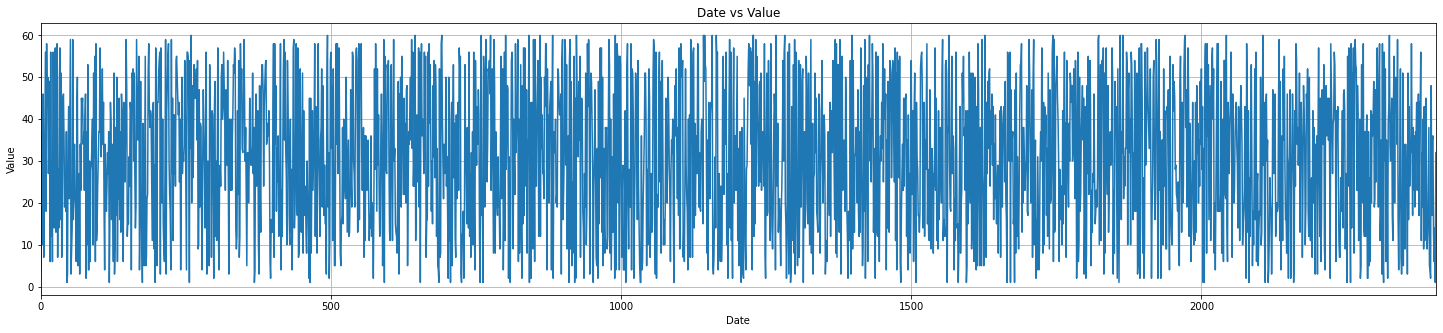

In [363]:
plt.title('Date vs Value')
plt.ylabel('Value')
plt.xlabel('Date')
plt.grid(True)
plt.autoscale(axis='x',tight=True)
plt.plot(mega_data[mega_field])

In [364]:
mega_data.columns

Index(['Sequence', 'Date', 'Value1', 'Value2', 'Value3', 'Value4', 'Value5',
       'Value6'],
      dtype='object')

In [365]:
all_data = mega_data[mega_field].values.astype(float)
print(all_data)

[ 4. 37. 10. ... 14.  1. 32.]


In [366]:
test_data_size = 12
train_data_size = len(all_data) - test_data_size
test_data = all_data[-test_data_size:]
train_data = all_data[:-test_data_size]
print(len(test_data))
print(len(train_data))
print(test_data)

12
2393
[ 5.  4.  2. 48. 17. 35. 36. 13.  6. 14.  1. 32.]


In [367]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
train_data_normalized = scaler.fit_transform(train_data .reshape(-1, 1))
print(train_data_normalized[:5])
print(train_data_normalized[-5:])

[[-0.89830508]
 [ 0.22033898]
 [-0.69491525]
 [ 0.38983051]
 [ 0.52542373]]
[[-0.49152542]
 [-0.72881356]
 [-0.59322034]
 [-0.18644068]
 [ 0.25423729]]


In [368]:
train_data_normalized = torch.FloatTensor(train_data_normalized).view(-1)
train_window = 24

In [369]:
def create_inout_sequences(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(L-tw):
        train_seq = input_data[i:i+tw]
        train_label = input_data[i+tw:i+tw+1]
        inout_seq.append((train_seq ,train_label))
    return inout_seq

train_inout_seq = create_inout_sequences(train_data_normalized, train_window)
train_inout_seq[:5]

[(tensor([-0.8983,  0.2203, -0.6949,  0.3898,  0.5254, -0.7966, -0.3220,  0.2542,
           0.8644, -0.4237,  0.9322,  0.4237,  0.6610, -0.1186,  0.0847,  0.6271,
          -0.8305,  0.8644, -0.6271, -0.0169, -0.8305,  0.8644,  0.6949, -0.5593]),
  tensor([0.8305])),
 (tensor([ 0.2203, -0.6949,  0.3898,  0.5254, -0.7966, -0.3220,  0.2542,  0.8644,
          -0.4237,  0.9322,  0.4237,  0.6610, -0.1186,  0.0847,  0.6271, -0.8305,
           0.8644, -0.6271, -0.0169, -0.8305,  0.8644,  0.6949, -0.5593,  0.8305]),
  tensor([0.8983])),
 (tensor([-0.6949,  0.3898,  0.5254, -0.7966, -0.3220,  0.2542,  0.8644, -0.4237,
           0.9322,  0.4237,  0.6610, -0.1186,  0.0847,  0.6271, -0.8305,  0.8644,
          -0.6271, -0.0169, -0.8305,  0.8644,  0.6949, -0.5593,  0.8305,  0.8983]),
  tensor([-0.5932])),
 (tensor([ 0.3898,  0.5254, -0.7966, -0.3220,  0.2542,  0.8644, -0.4237,  0.9322,
           0.4237,  0.6610, -0.1186,  0.0847,  0.6271, -0.8305,  0.8644, -0.6271,
          -0.0169, -0.8305, 

In [370]:
class LSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=60, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.lstm = nn.LSTM(input_size, hidden_layer_size)
        self.linear = nn.Linear(hidden_layer_size, output_size)
        self.hidden_cell = (torch.zeros(1,1,self.hidden_layer_size),
                            torch.zeros(1,1,self.hidden_layer_size))
    def forward(self, input_seq):
        lstm_out, self.hidden_cell = self.lstm(input_seq.view(len(input_seq) ,1, -1), 
                                     self.hidden_cell)
        predictions = self.linear(lstm_out.view(len(input_seq), -1))
        return predictions[-1]

In [371]:
class GRU(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=60, output_size=1):
        super().__init__()
        self.hidden_layer_size = hidden_layer_size
        self.gru = nn.GRU(input_size, hidden_layer_size)
        self.linear = nn.Linear(hidden_layer_size, output_size)
        self.hidden_cell = (torch.zeros(1,1,self.hidden_layer_size),
                            torch.zeros(1,1,self.hidden_layer_size))
    def forward(self, input_seq):
        gru_out, self.hidden_cell = self.gru(input_seq.view(len(input_seq) ,1, -1), 
                                    self.hidden_cell)
        predictions = self.linear(gru_out.view(len(input_seq), -1))
        return predictions[-1]

In [372]:
model = LSTM()
#model = GRU()
loss_function = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
print(model)

LSTM(
  (lstm): LSTM(1, 60)
  (linear): Linear(in_features=60, out_features=1, bias=True)
)


In [373]:
epochs = 12

for i in range(epochs):
    for seq, labels in train_inout_seq:
        optimizer.zero_grad()
        model.hidden_cell = (torch.zeros(1, 1, model.hidden_layer_size),
                        torch.zeros(1, 1, model.hidden_layer_size))
        y_pred = model(seq)
        single_loss = loss_function(y_pred, labels)
        single_loss.backward()
        optimizer.step()
    print(f'epoch: {i:3} loss: {single_loss.item():10.8f}')

print(' ')
print(f'epoch: {i:3} loss: {single_loss.item():10.12f}')

epoch:   0 loss: 0.05072205
epoch:   1 loss: 0.05151573
epoch:   2 loss: 0.05185801
epoch:   3 loss: 0.05339304
epoch:   4 loss: 0.05462384
epoch:   5 loss: 0.05547113
epoch:   6 loss: 0.05639945
epoch:   7 loss: 0.05755800
epoch:   8 loss: 0.05623662
epoch:   9 loss: 0.05490116
epoch:  10 loss: 0.06104406
epoch:  11 loss: 0.06486584
 
epoch:  11 loss: 0.064865835011


In [374]:
test_inputs = train_data_normalized[-train_window:].tolist()
print(test_inputs)

[0.22033898532390594, 0.18644067645072937, 0.4576271176338196, -0.2542372941970825, 0.2881355881690979, 0.5254237055778503, -0.4576271176338196, 0.4576271176338196, 0.35593220591545105, 0.8644067645072937, -0.6610169410705566, 0.050847455859184265, -0.38983049988746643, 0.32203391194343567, -0.7288135886192322, 0.4237288236618042, -0.6610169410705566, -0.016949152573943138, 0.49152541160583496, -0.49152541160583496, -0.7288135886192322, -0.5932203531265259, -0.18644067645072937, 0.2542372941970825]


In [375]:
model.eval()

for i in range(test_data_size):
    seq = torch.FloatTensor(test_inputs[-train_window:])
    with torch.no_grad():
        model.hidden = (torch.zeros(1, 1, model.hidden_layer_size),
                        torch.zeros(1, 1, model.hidden_layer_size))
        test_inputs.append(model(seq).item())

test_inputs[test_data_size:]

[-0.38983049988746643,
 0.32203391194343567,
 -0.7288135886192322,
 0.4237288236618042,
 -0.6610169410705566,
 -0.016949152573943138,
 0.49152541160583496,
 -0.49152541160583496,
 -0.7288135886192322,
 -0.5932203531265259,
 -0.18644067645072937,
 0.2542372941970825,
 -0.0051867347210645676,
 -0.006160061806440353,
 -0.0027663148939609528,
 -0.0025139804929494858,
 -0.003277391195297241,
 -0.0032840538769960403,
 -0.003139207139611244,
 -0.0031546615064144135,
 -0.003186902031302452,
 -0.0031828973442316055,
 -0.0031772274523973465,
 -0.003178788349032402]

In [376]:
actual_predictions = scaler.inverse_transform(np.array(test_inputs[train_window:] ).reshape(-1, 1))
print(actual_predictions)

[[30.34699133]
 [30.31827818]
 [30.41839371]
 [30.42583758]
 [30.40331696]
 [30.40312041]
 [30.40739339]
 [30.40693749]
 [30.40598639]
 [30.40610453]
 [30.40627179]
 [30.40622574]]


In [377]:
new_data = np.arange(train_data_size, train_data_size + test_data_size, 1)
print(new_data)

[2393 2394 2395 2396 2397 2398 2399 2400 2401 2402 2403 2404]


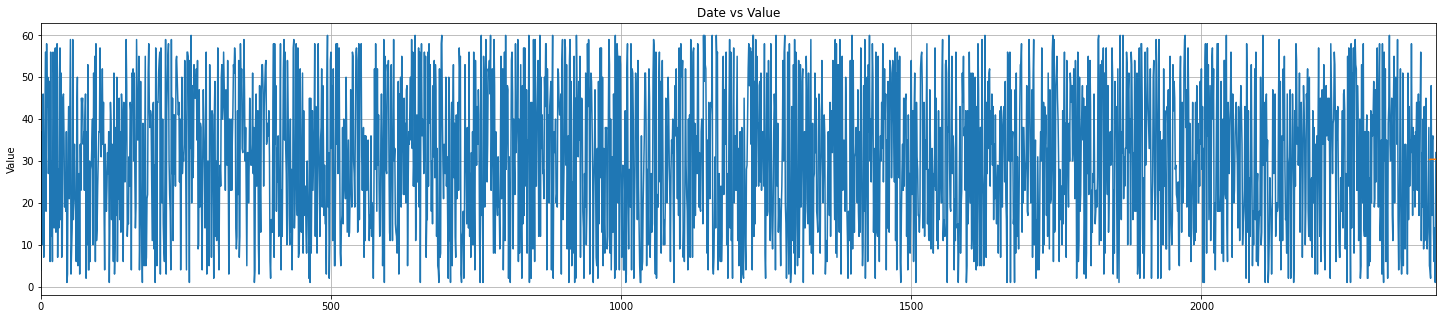

In [378]:
plt.title('Date vs Value')
plt.ylabel('Value')
plt.grid(True)
plt.autoscale(axis='x', tight=True)
plt.plot(mega_data[mega_field])
plt.plot(new_data,actual_predictions)
plt.show()

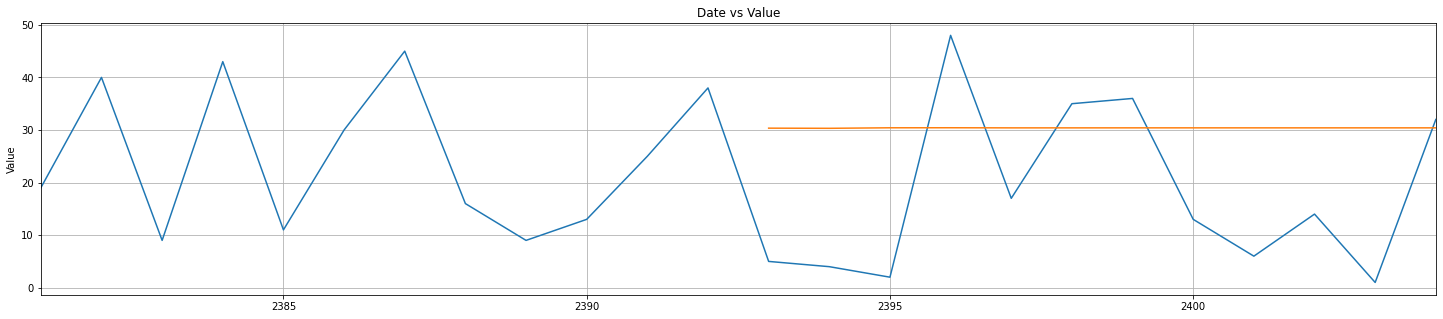

In [379]:
plt.title('Date vs Value')
plt.ylabel('Value')
plt.grid(True)
plt.autoscale(axis='x', tight=True)
plt.plot(mega_data[mega_field][-train_window:])
plt.plot(new_data,actual_predictions)
plt.show()

In [380]:
print(actual_predictions[0])
print(actual_predictions[1])

[30.34699133]
[30.31827818]
